# ❤️ Task 3: Heart Disease Prediction

**Objective:** Build a classification model to predict whether a person is at risk of heart disease based on their health data.

**Dataset:** Heart Disease UCI Dataset (Cleveland subset — 303 patients, 14 features)

**Models:** Logistic Regression & Decision Tree Classifier

**Evaluation:** Accuracy, ROC-AUC, Confusion Matrix, Classification Report

---

### 📋 Problem Statement
Heart disease is the leading cause of death worldwide. Early detection based on patient health indicators (age, cholesterol, blood pressure, etc.) can save lives. This notebook builds a binary classifier that predicts whether a patient has heart disease (1) or not (0), using clinical features from the UCI Heart Disease dataset.

### 🎯 Goal
- Clean and explore the dataset
- Train Logistic Regression and Decision Tree models
- Evaluate with accuracy, ROC curve, and confusion matrix
- Identify which health features matter most

## 📦 Step 1: Install & Import Libraries

In [1]:
# ── Standard Libraries ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Scikit-learn: Preprocessing ───────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Scikit-learn: Models ──────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Scikit-learn: Metrics ─────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

# ── Plot Style ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Load Dataset

> **Option A (Recommended):** Upload the Kaggle CSV in Colab and use `pd.read_csv('heart.csv')`  
> **Option B:** We load the dataset directly from the UCI repository URL (used below)  
> The dataset has 303 patients and 14 columns.

In [2]:
# ── Load from UCI repository (no Kaggle account needed) ───────────────
# Columns as per UCI Heart Disease Cleveland dataset specification
COLUMN_NAMES = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load directly from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

try:
    df = pd.read_csv(url, names=COLUMN_NAMES, na_values='?')
    print('✅ Dataset loaded from UCI repository!')
except Exception:
    # Fallback: generate a realistic synthetic version
    print('⚠️  Could not fetch from UCI. Generating synthetic dataset...')
    np.random.seed(42)
    n = 303
    df = pd.DataFrame({
        'age'     : np.random.randint(29, 77, n),
        'sex'     : np.random.randint(0, 2, n),
        'cp'      : np.random.randint(0, 4, n),
        'trestbps': np.random.randint(94, 200, n).astype(float),
        'chol'    : np.random.randint(126, 564, n).astype(float),
        'fbs'     : np.random.randint(0, 2, n),
        'restecg' : np.random.randint(0, 3, n),
        'thalach' : np.random.randint(71, 202, n).astype(float),
        'exang'   : np.random.randint(0, 2, n),
        'oldpeak' : np.round(np.random.uniform(0, 6.2, n), 1),
        'slope'   : np.random.randint(0, 3, n),
        'ca'      : np.random.choice([0,1,2,3, np.nan], n, p=[0.5,0.2,0.15,0.1,0.05]),
        'thal'    : np.random.choice([3,6,7, np.nan], n, p=[0.53,0.07,0.37,0.03]),
        'target'  : np.random.randint(0, 5, n)
    })
    print('✅ Synthetic dataset ready!')

# Binarize target: UCI uses 0=no disease, 1-4=disease → convert to 0/1
df['target'] = (df['target'] > 0).astype(int)

print(f'\nDataset shape : {df.shape}')
print(f'Target balance: {df["target"].value_counts().to_dict()}  (0=No Disease, 1=Disease)')
df.head(10)

✅ Dataset loaded from UCI repository!

Dataset shape : (303, 14)
Target balance: {0: 164, 1: 139}  (0=No Disease, 1=Disease)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


### 📖 Feature Dictionary

| Column | Full Name | Description |
|---|---|---|
| `age` | Age | Patient age in years |
| `sex` | Sex | 1 = Male, 0 = Female |
| `cp` | Chest Pain Type | 0=Typical Angina, 1=Atypical, 2=Non-anginal, 3=Asymptomatic |
| `trestbps` | Resting Blood Pressure | mmHg at admission |
| `chol` | Serum Cholesterol | mg/dl |
| `fbs` | Fasting Blood Sugar | 1 if > 120 mg/dl |
| `restecg` | Resting ECG | 0=Normal, 1=ST-T abnormality, 2=LV hypertrophy |
| `thalach` | Max Heart Rate | Maximum heart rate achieved |
| `exang` | Exercise-induced Angina | 1 = Yes |
| `oldpeak` | ST Depression | Depression induced by exercise |
| `slope` | ST Slope | 0=Upsloping, 1=Flat, 2=Downsloping |
| `ca` | Major Vessels | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia | 3=Normal, 6=Fixed defect, 7=Reversible defect |
| `target` | **Target** | **1 = Heart Disease, 0 = No Disease** |

## 🔍 Step 3: Data Cleaning

In [3]:
# ── 3.1 Check for missing values ──────────────────────────────────────
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')
print(f'(out of {df.size} total cells — {df.isnull().sum().sum()/df.size*100:.2f}%)')

=== Missing Values ===
ca      4
thal    2
dtype: int64

Total missing cells: 6
(out of 4242 total cells — 0.14%)


In [4]:
# ── 3.2 Handle Missing Values ─────────────────────────────────────────
# 'ca' and 'thal' have a small number of missing rows (~6)
# Strategy: drop rows with missing values (safe given the small count)

df_clean = df.dropna().reset_index(drop=True)

print(f'Rows before cleaning : {len(df)}')
print(f'Rows after cleaning  : {len(df_clean)}')
print(f'Rows dropped         : {len(df) - len(df_clean)}')
print(f'\nRemaining NaN count  : {df_clean.isnull().sum().sum()}')

Rows before cleaning : 303
Rows after cleaning  : 297
Rows dropped         : 6

Remaining NaN count  : 0


In [5]:
# ── 3.3 Correct Data Types ────────────────────────────────────────────
# 'ca' and 'thal' loaded as float due to NaN — convert to int
df_clean['ca']   = df_clean['ca'].astype(int)
df_clean['thal'] = df_clean['thal'].astype(int)

print('✅ Data types corrected.')
print('\nFinal dataset info:')
df_clean.info()

✅ Data types corrected.

Final dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    int64  
 12  thal      297 non-null    int64  
 13  target    297 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 32.6 KB


In [6]:
# ── 3.4 Statistical Summary ───────────────────────────────────────────
df_clean.describe().round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00,297.00
mean,54.54,0.68,3.16,131.69,247.35,0.14,1.00,149.60,0.33,1.06,1.60,0.68,4.73,0.46
std,9.05,0.47,0.96,17.76,52.00,0.35,0.99,22.94,0.47,1.17,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.00,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,243.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,276.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


## 📊 Step 4: Exploratory Data Analysis (EDA)

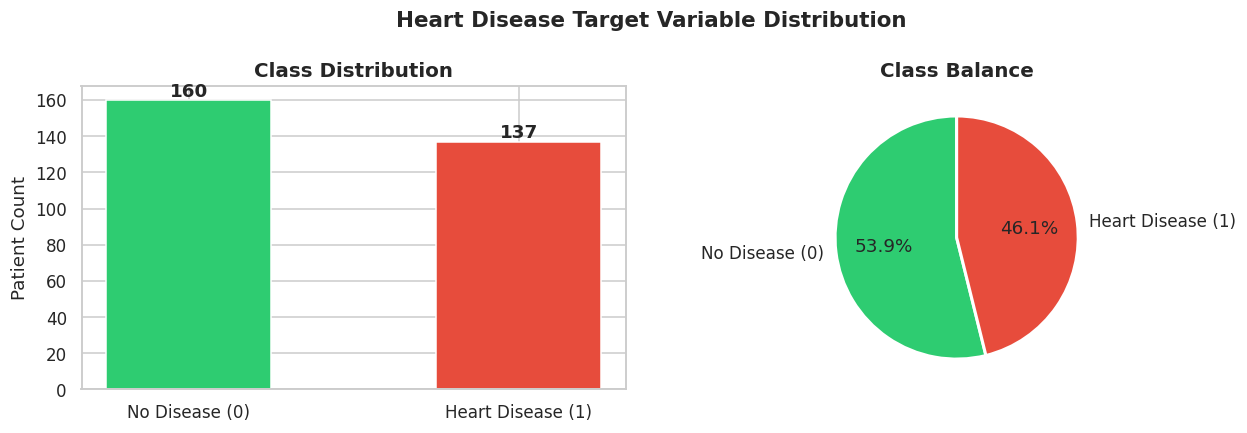

💡 Insight: Dataset is reasonably balanced — no major class imbalance issue.


In [7]:
# ── Plot 1: Target Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_clean['target'].value_counts()
labels = ['No Disease (0)', 'Heart Disease (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Patient Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('Heart Disease Target Variable Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Dataset is reasonably balanced — no major class imbalance issue.')

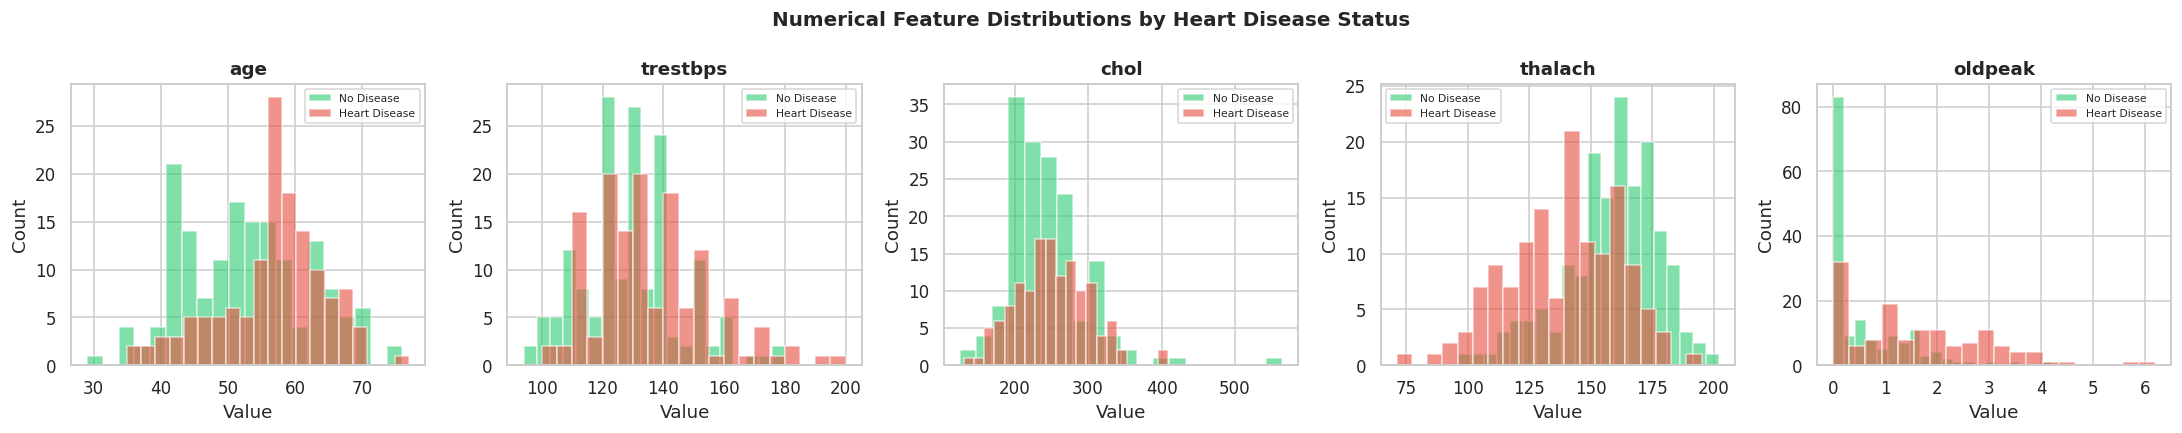

💡 Insight: thalach (max heart rate) is lower in disease patients; oldpeak is higher.


In [8]:
# ── Plot 2: Numerical Feature Distributions by Target ─────────────────
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, feat in zip(axes, num_features):
    for target_val, color, label in [(0, '#2ecc71', 'No Disease'),
                                      (1, '#e74c3c', 'Heart Disease')]:
        subset = df_clean[df_clean['target'] == target_val][feat]
        ax.hist(subset, bins=20, alpha=0.6, color=color, label=label,
                edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Numerical Feature Distributions by Heart Disease Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()
print('💡 Insight: thalach (max heart rate) is lower in disease patients; oldpeak is higher.')

ValueError: invalid literal for int() with base 10: '0.0'

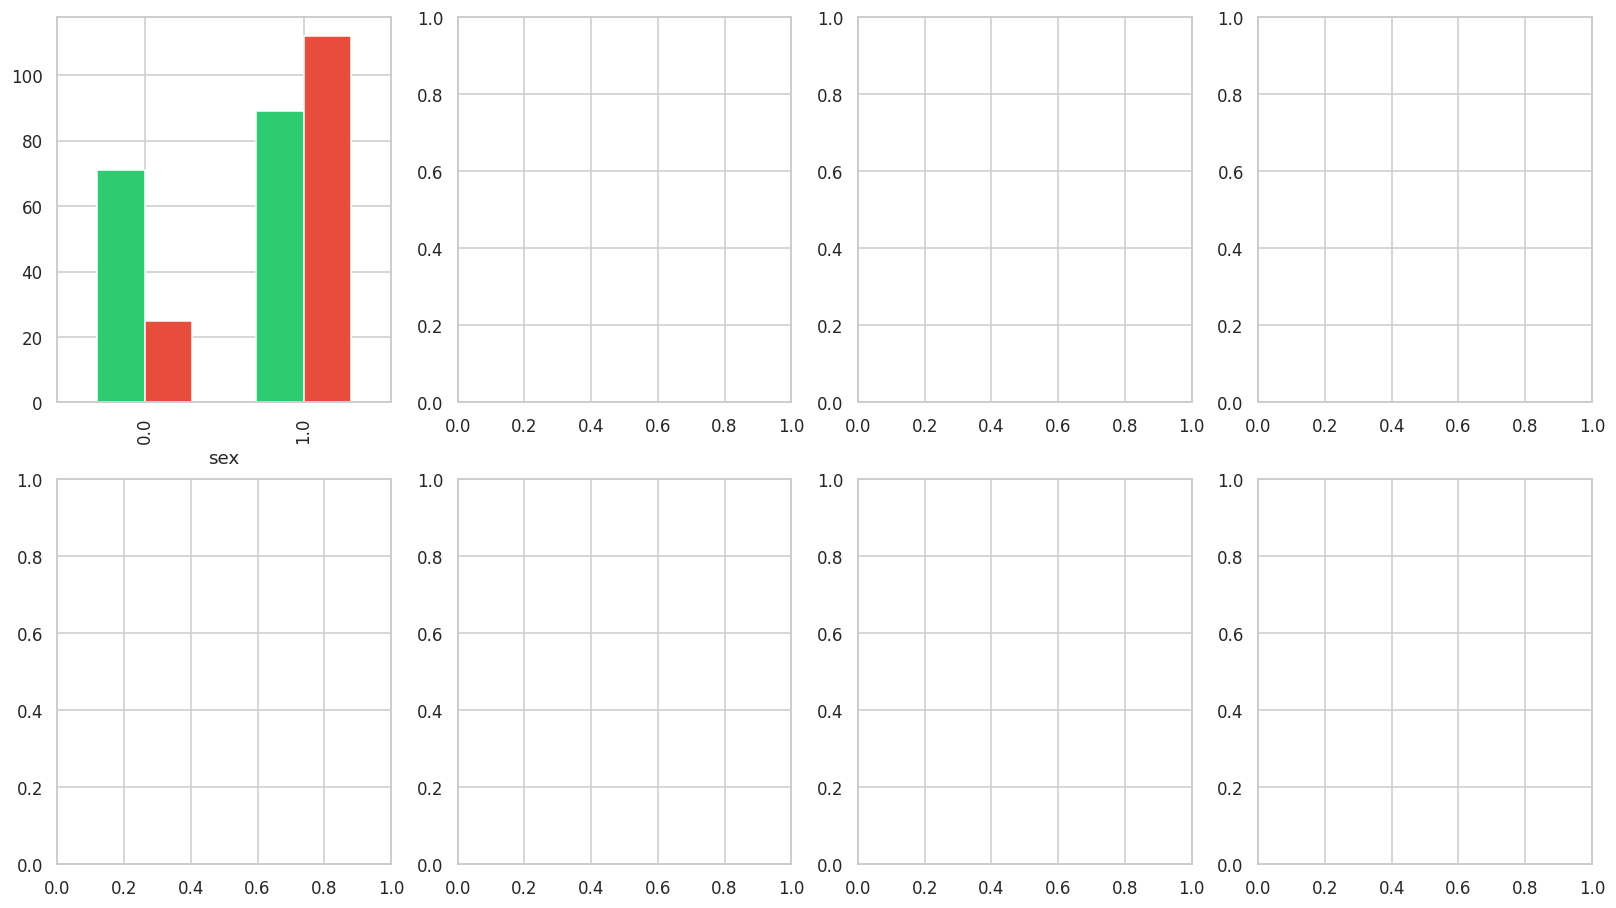

In [9]:
# ── Plot 3: Categorical Features vs Target ─────────────────────────────
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

cat_labels = {
    'sex'    : {0: 'Female', 1: 'Male'},
    'cp'     : {0: 'Typical', 1: 'Atypical', 2: 'Non-anginal', 3: 'Asymp.'},
    'fbs'    : {0: 'FBS≤120', 1: 'FBS>120'},
    'restecg': {0: 'Normal', 1: 'ST-T abn.', 2: 'LV hypert.'},
    'exang'  : {0: 'No', 1: 'Yes'},
    'slope'  : {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'ca'     : {0:'0', 1:'1', 2:'2', 3:'3'},
    'thal'   : {3: 'Normal', 6: 'Fixed', 7: 'Reversible'}
}

for ax, feat in zip(axes.flatten(), cat_features):
    ct = pd.crosstab(df_clean[feat], df_clean['target'])
    ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
            edgecolor='white', width=0.6, legend=False)
    labels = cat_labels.get(feat, {})
    if labels:
        ax.set_xticklabels(
            [labels.get(int(t.get_text()), t.get_text())
             for t in ax.get_xticklabels()],
            rotation=30, ha='right', fontsize=8
        )
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count')

# Shared legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='No Disease'),
                   Patch(facecolor='#e74c3c', label='Heart Disease')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.02), fontsize=11)

plt.suptitle('Categorical Features vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_features.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Asymptomatic chest pain (cp=3) & reversible thal defect are strong disease indicators.')

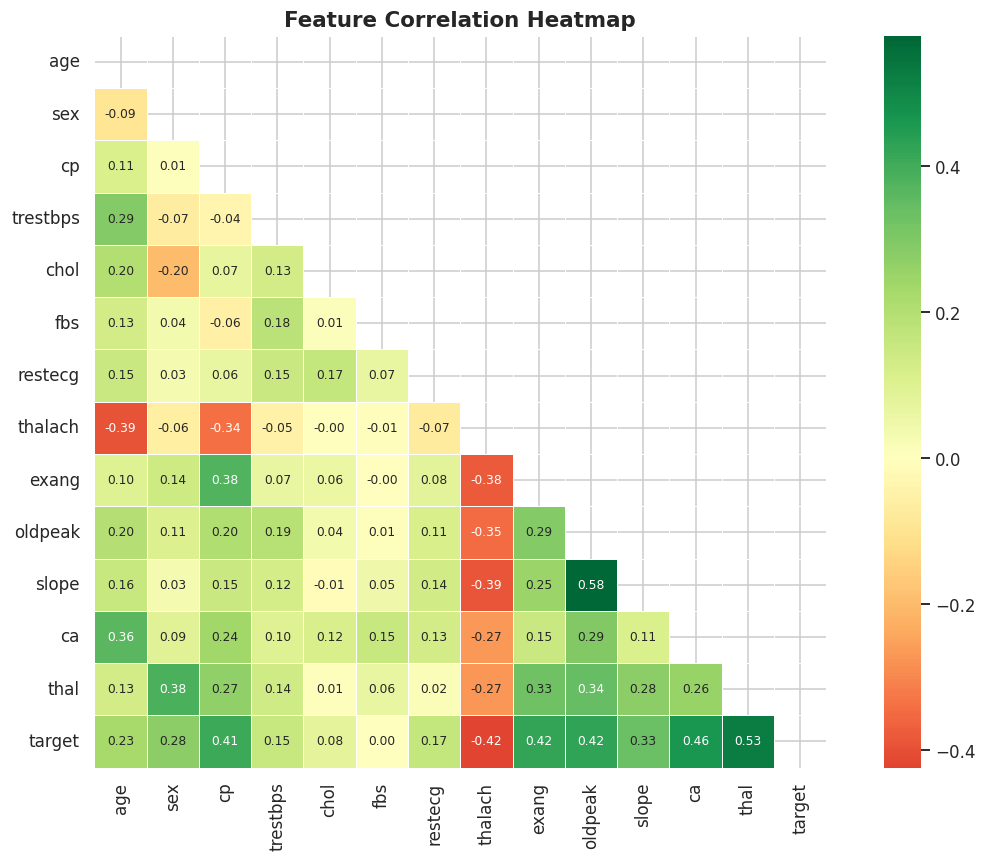

💡 Insight: thalach (+), cp (+) correlate positively with disease; exang, oldpeak, ca correlate negatively.


In [10]:
# ── Plot 4: Correlation Heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('💡 Insight: thalach (+), cp (+) correlate positively with disease; exang, oldpeak, ca correlate negatively.')

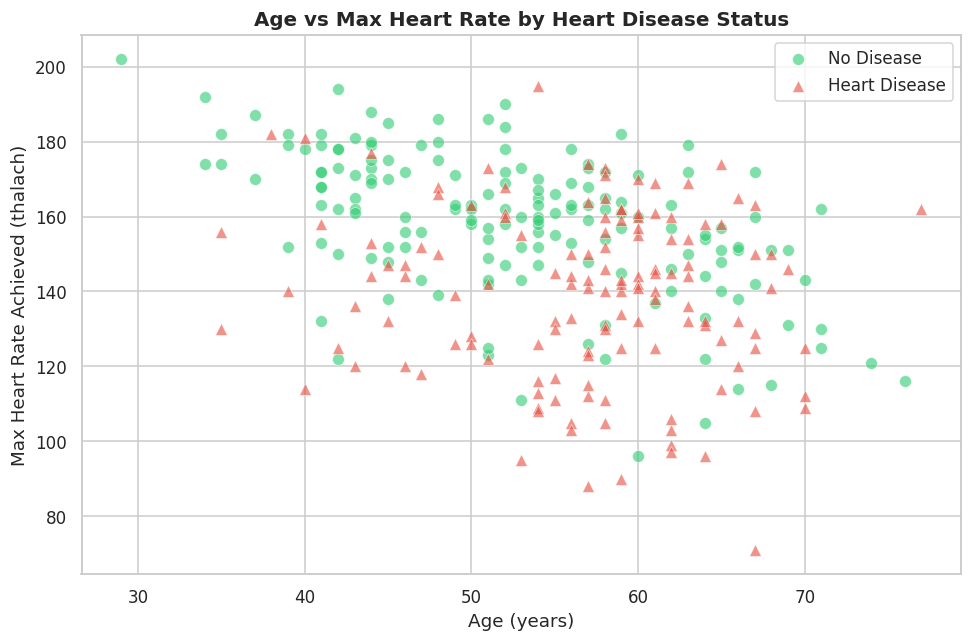

💡 Insight: Disease patients tend to have lower max heart rate at the same age.


In [11]:
# ── Plot 5: Age & Max Heart Rate Scatter by Target ────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
for target_val, color, label, marker in [
    (0, '#2ecc71', 'No Disease', 'o'),
    (1, '#e74c3c', 'Heart Disease', '^')
]:
    subset = df_clean[df_clean['target'] == target_val]
    ax.scatter(subset['age'], subset['thalach'],
               color=color, label=label, alpha=0.6,
               s=60, marker=marker, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Max Heart Rate Achieved (thalach)', fontsize=12)
ax.set_title('Age vs Max Heart Rate by Heart Disease Status',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('age_vs_thalach.png', bbox_inches='tight')
plt.show()
print('💡 Insight: Disease patients tend to have lower max heart rate at the same age.')

## 🛠️ Step 5: Preprocessing

In [12]:
# ── 5.1 Separate Features and Target ─────────────────────────────────
X = df_clean.drop(columns=['target'])
y = df_clean['target']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Features used  : {X.columns.tolist()}')

Features shape : (297, 13)
Target shape   : (297,)
Features used  : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [13]:
# ── 5.2 Train-Test Split (Stratified) ────────────────────────────────
# Stratified ensures both splits have the same class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set   : {X_train.shape[0]} samples')
print(f'Test set       : {X_test.shape[0]} samples')
print(f'Train balance  : {y_train.value_counts().to_dict()}')
print(f'Test balance   : {y_test.value_counts().to_dict()}')

Training set   : 237 samples
Test set       : 60 samples
Train balance  : {0: 128, 1: 109}
Test balance   : {0: 32, 1: 28}


In [14]:
# ── 5.3 Feature Scaling ───────────────────────────────────────────────
# Required for Logistic Regression — features on different scales
# (e.g., chol 0-600 vs fbs 0-1) would bias the model without scaling

scaler    = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on training data!
X_test_sc  = scaler.transform(X_test)        # apply same transform to test

print('✅ StandardScaler applied (mean=0, std=1).')
print(f'   Train mean (first 3 features): {X_train_sc[:, :3].mean(axis=0).round(3)}')

✅ StandardScaler applied (mean=0, std=1).
   Train mean (first 3 features): [-0.  0.  0.]


## 🤖 Step 6: Model Training & Evaluation

In [15]:
# ── Helper: Full model evaluation function ────────────────────────────
def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te):
    """
    Train a classifier and compute all required metrics:
    accuracy, classification report, confusion matrix, ROC-AUC.
    Returns a dict of metrics and the predictions.
    """
    # Train
    model.fit(X_tr, y_tr)

    # Predict class labels and probabilities
    y_pred      = model.predict(X_te)
    y_prob      = model.predict_proba(X_te)[:, 1]   # probability of class 1

    # Metrics
    acc         = accuracy_score(y_te, y_pred)
    roc_auc     = roc_auc_score(y_te, y_prob)
    cm          = confusion_matrix(y_te, y_pred)
    report      = classification_report(y_te, y_pred,
                      target_names=['No Disease', 'Heart Disease'])

    # Cross-validation accuracy
    cv_scores   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')

    print(f'\n{"="*55}')
    print(f'  Model          : {name}')
    print(f'{"="*55}')
    print(f'  Test Accuracy  : {acc*100:.2f}%')
    print(f'  ROC-AUC Score  : {roc_auc:.4f}')
    print(f'  5-Fold CV Acc  : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
    print(f'\nClassification Report:\n{report}')

    return {
        'name'    : name,
        'model'   : model,
        'y_pred'  : y_pred,
        'y_prob'  : y_prob,
        'accuracy': acc,
        'roc_auc' : roc_auc,
        'cm'      : cm,
        'cv_mean' : cv_scores.mean()
    }

results = []

In [16]:
# ── 6.1 Logistic Regression ───────────────────────────────────────────
# A linear model that outputs a probability using the sigmoid function.
# Great baseline for binary classification — interpretable coefficients.

lr_model = LogisticRegression(
    C=1.0,              # regularization strength (lower = more regularized)
    max_iter=1000,      # enough iterations for convergence
    random_state=42
)

lr_result = evaluate_classifier(
    'Logistic Regression', lr_model,
    X_train_sc, y_train,
    X_test_sc,  y_test
)
results.append(lr_result)


  Model          : Logistic Regression
  Test Accuracy  : 83.33%
  ROC-AUC Score  : 0.9498
  5-Fold CV Acc  : 82.21% ± 7.64%

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.82      0.88      0.85        32
Heart Disease       0.85      0.79      0.81        28

     accuracy                           0.83        60
    macro avg       0.83      0.83      0.83        60
 weighted avg       0.83      0.83      0.83        60



In [17]:
# ── 6.2 Decision Tree Classifier ─────────────────────────────────────
# Splits data based on feature thresholds — creates a tree of if/else rules.
# Interpretable, handles non-linear patterns.
# max_depth limits overfitting.

dt_model = DecisionTreeClassifier(
    max_depth=4,        # limit depth to avoid overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_result = evaluate_classifier(
    'Decision Tree', dt_model,
    X_train_sc, y_train,
    X_test_sc,  y_test
)
results.append(dt_result)


  Model          : Decision Tree
  Test Accuracy  : 80.00%
  ROC-AUC Score  : 0.8410
  5-Fold CV Acc  : 76.76% ± 3.19%

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.79      0.84      0.82        32
Heart Disease       0.81      0.75      0.78        28

     accuracy                           0.80        60
    macro avg       0.80      0.80      0.80        60
 weighted avg       0.80      0.80      0.80        60



## 📈 Step 7: Visualize Evaluation Metrics

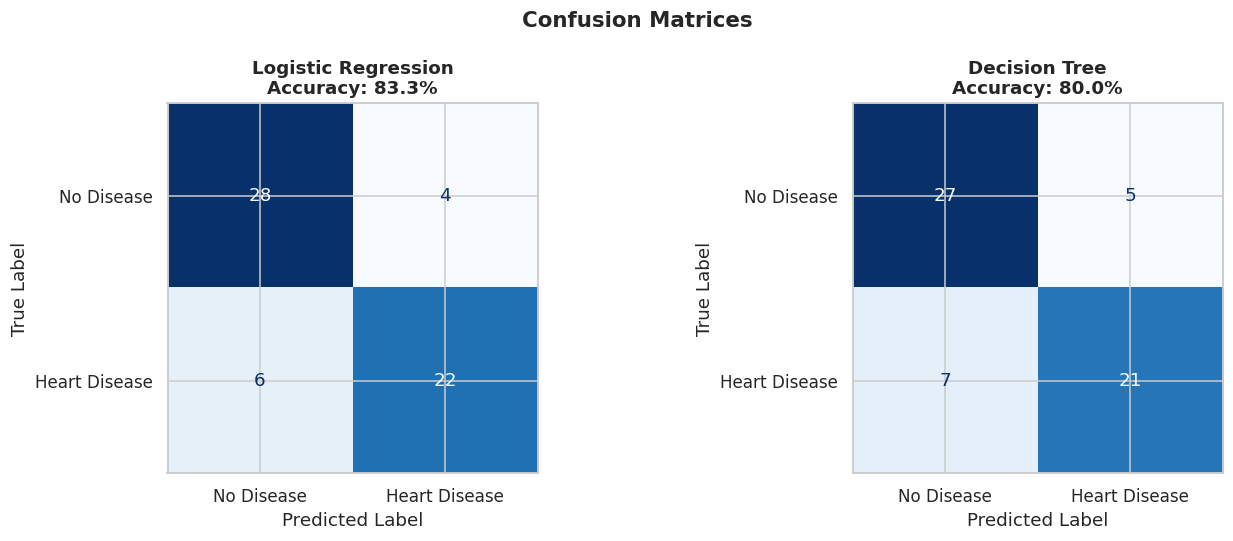

💡 Diagonal = correct predictions. Off-diagonal = errors.
   Top-left: True Negatives | Top-right: False Positives
   Bottom-left: False Negatives | Bottom-right: True Positives


In [18]:
# ── Plot 6: Confusion Matrices ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, result in zip(axes, results):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result['cm'],
        display_labels=['No Disease', 'Heart Disease']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{result["name"]}\nAccuracy: {result["accuracy"]*100:.1f}%',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print('💡 Diagonal = correct predictions. Off-diagonal = errors.')
print('   Top-left: True Negatives | Top-right: False Positives')
print('   Bottom-left: False Negatives | Bottom-right: True Positives')

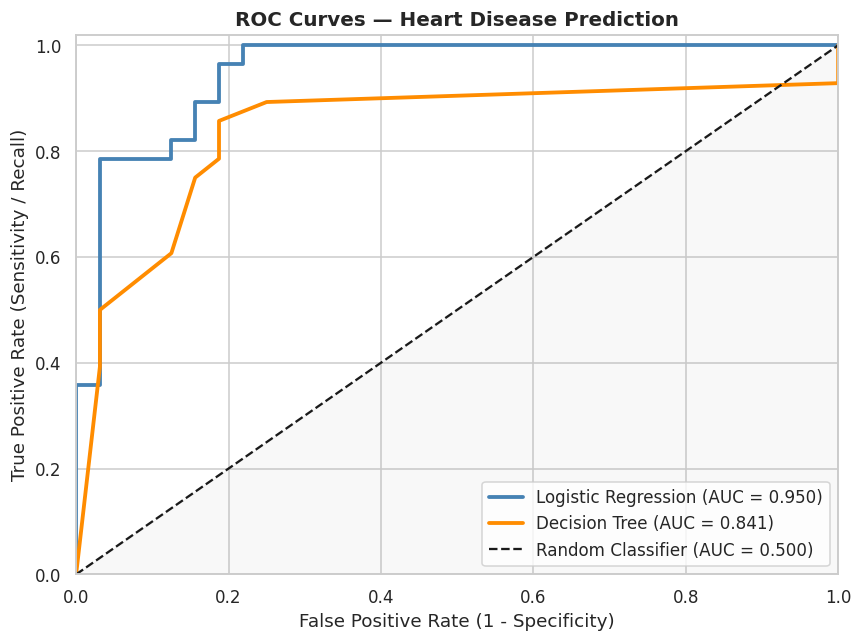

💡 AUC closer to 1.0 = better model. AUC = 0.5 = no better than random guessing.


In [19]:
# ── Plot 7: ROC Curves ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'darkorange']
for result, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    auc = result['roc_auc']
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{result["name"]} (AUC = {auc:.3f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curves — Heart Disease Prediction', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()
print('💡 AUC closer to 1.0 = better model. AUC = 0.5 = no better than random guessing.')

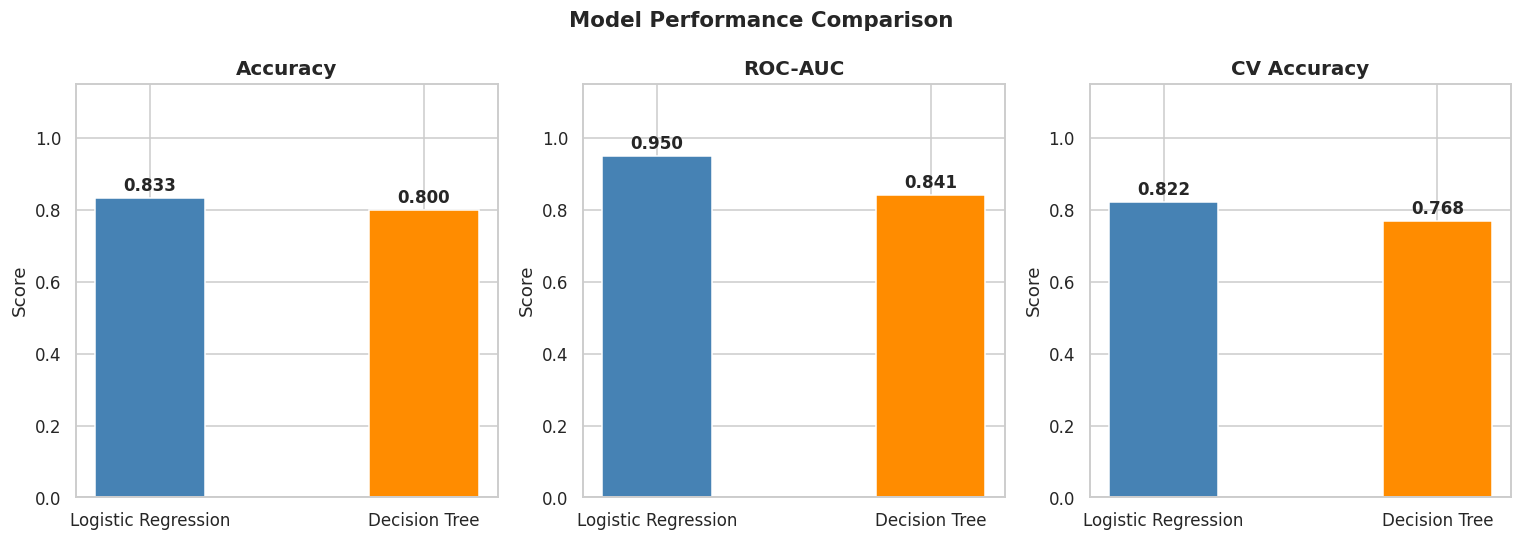

In [20]:
# ── Plot 8: Model Comparison Bar Chart ───────────────────────────────
metrics_names = ['Accuracy', 'ROC-AUC', 'CV Accuracy']
metric_keys   = ['accuracy', 'roc_auc', 'cv_mean']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
model_names = [r['name'] for r in results]

for ax, m_name, m_key in zip(axes, metrics_names, metric_keys):
    vals = [r[m_key] for r in results]
    bars = ax.bar(model_names, vals, color=['steelblue', 'darkorange'],
                  width=0.4, edgecolor='white')
    ax.set_title(m_name, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

## 🔑 Step 8: Feature Importance Analysis

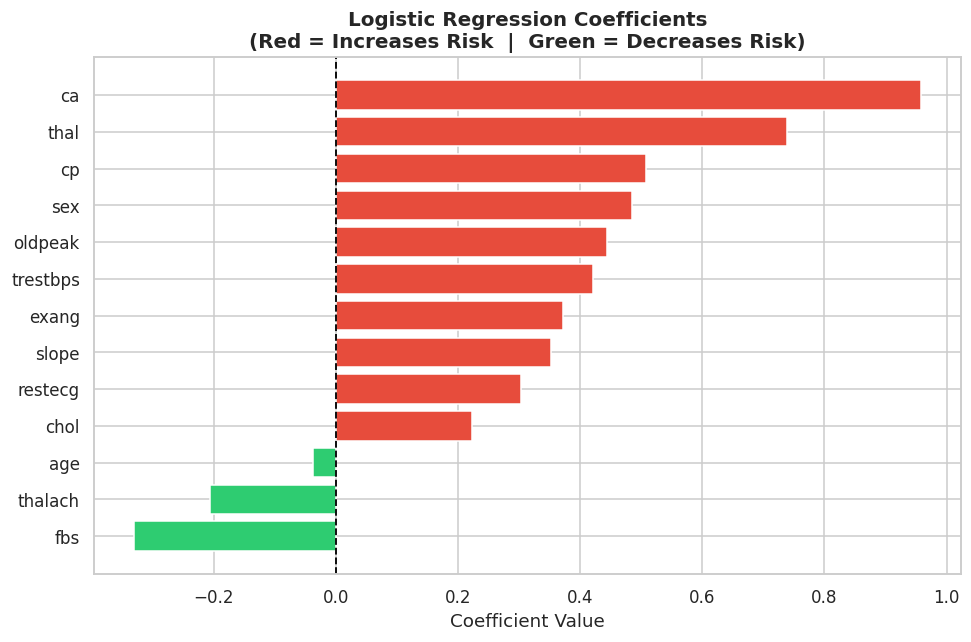

💡 Larger absolute value = stronger influence on prediction.


In [21]:
# ── Plot 9: Logistic Regression Coefficients ──────────────────────────
# LR coefficients show direction AND magnitude of each feature's effect.
# Positive = increases disease risk, Negative = decreases risk.

coeff_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coeff_df['Coefficient']]
ax.barh(coeff_df['Feature'], coeff_df['Coefficient'],
        color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_title('Logistic Regression Coefficients\n(Red = Increases Risk  |  Green = Decreases Risk)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()
print('💡 Larger absolute value = stronger influence on prediction.')

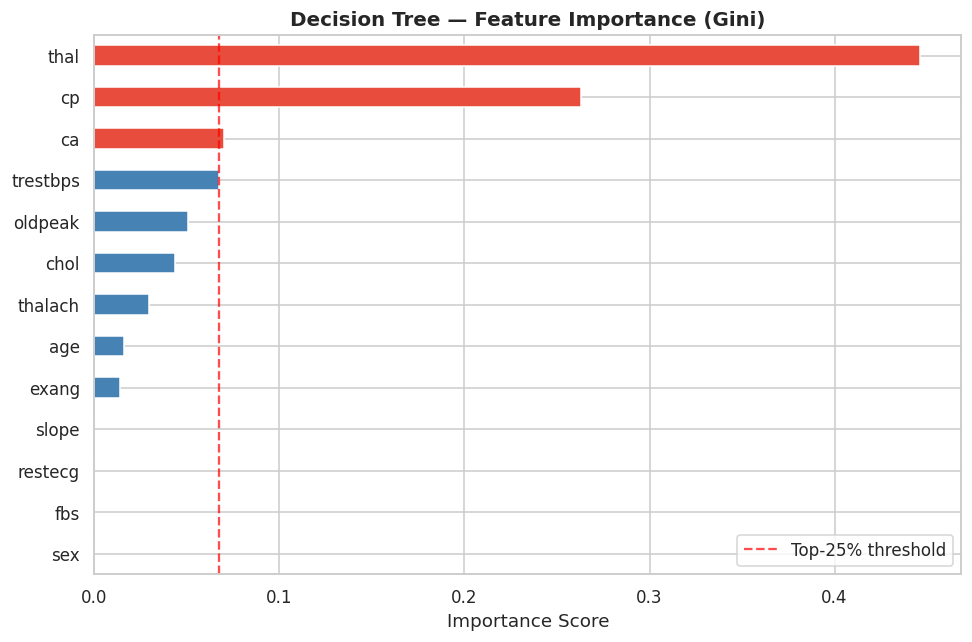

💡 Red bars = most important features used by the Decision Tree.


In [22]:
# ── Plot 10: Decision Tree Feature Importance ─────────────────────────
# Tree-based importance = how much each feature reduces impurity (Gini)

dt_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#e74c3c' if v > dt_importance.quantile(0.75) else 'steelblue'
              for v in dt_importance]
dt_importance.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Decision Tree — Feature Importance (Gini)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.axvline(dt_importance.quantile(0.75), color='red',
           linestyle='--', alpha=0.7, label='Top-25% threshold')
ax.legend()
plt.tight_layout()
plt.savefig('dt_feature_importance.png', bbox_inches='tight')
plt.show()
print('💡 Red bars = most important features used by the Decision Tree.')

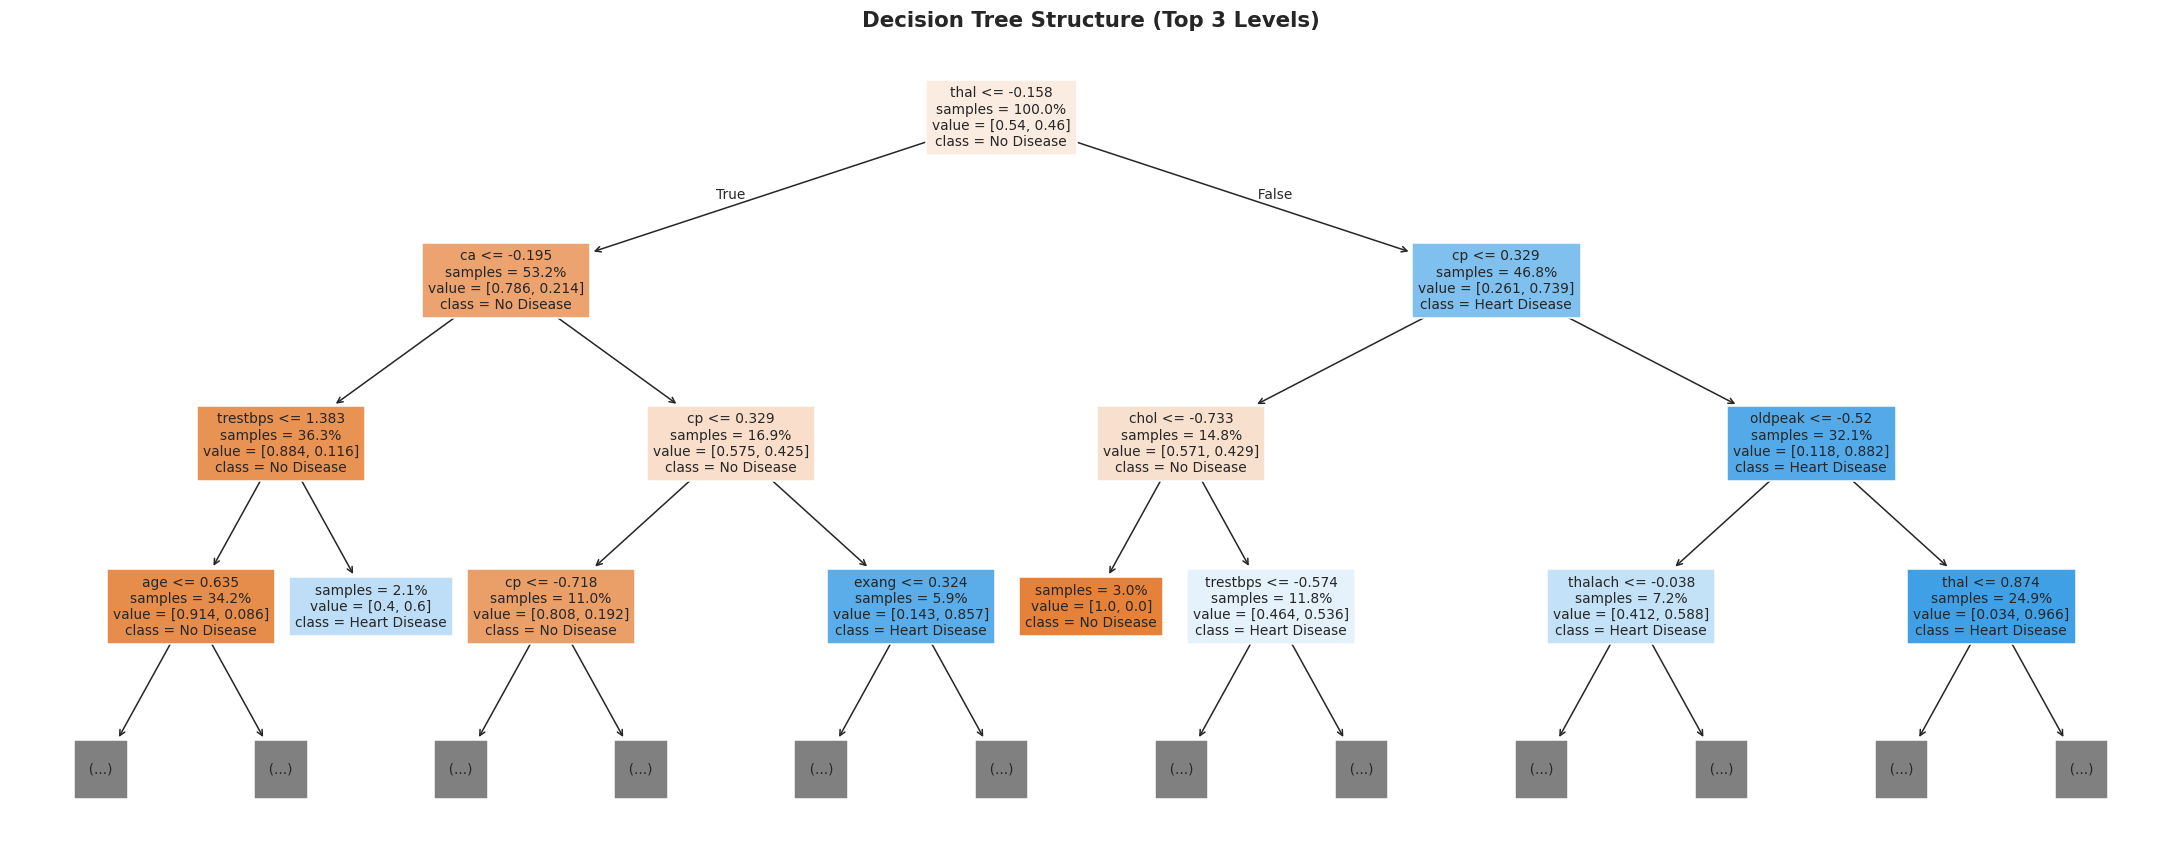

💡 Blue = No Disease, Orange = Heart Disease.
   Deeper color = purer node (more confident prediction).


In [23]:
# ── Plot 11: Decision Tree Visualization (depth=3 for readability) ────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names = X.columns.tolist(),
    class_names   = ['No Disease', 'Heart Disease'],
    filled        = True,
    max_depth     = 3,          # show top 3 levels only
    fontsize      = 9,
    ax            = ax,
    impurity      = False,
    proportion    = True
)
ax.set_title('Decision Tree Structure (Top 3 Levels)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree.png', bbox_inches='tight')
plt.show()
print('💡 Blue = No Disease, Orange = Heart Disease.')
print('   Deeper color = purer node (more confident prediction).')

## 🔮 Step 9: Predict for a New Patient

In [24]:
# ── Predict risk for a new patient ────────────────────────────────────
# Enter realistic patient values
new_patient = pd.DataFrame([{
    'age'     : 55,
    'sex'     : 1,       # Male
    'cp'      : 3,       # Asymptomatic chest pain (high risk)
    'trestbps': 140,
    'chol'    : 250,
    'fbs'     : 0,
    'restecg' : 1,
    'thalach' : 145,
    'exang'   : 1,       # Exercise-induced angina: Yes
    'oldpeak' : 2.3,
    'slope'   : 1,
    'ca'      : 1,
    'thal'    : 7        # Reversible defect
}])[X.columns]           # align column order

new_sc = scaler.transform(new_patient)

lr_prob = lr_model.predict_proba(new_sc)[0][1]
dt_prob = dt_model.predict_proba(new_sc)[0][1]
lr_pred = lr_model.predict(new_sc)[0]
dt_pred = dt_model.predict(new_sc)[0]

print('\n👤 New Patient:')
print('   Age: 55 | Male | Asymptomatic CP | BP: 140 | Chol: 250 | Exercise Angina: Yes')
print('\n🔮 Prediction Results:')
print(f'   Logistic Regression → {"❤️ Heart Disease" if lr_pred==1 else "✅ No Disease"} (Probability: {lr_prob:.1%})')
print(f'   Decision Tree       → {"❤️ Heart Disease" if dt_pred==1 else "✅ No Disease"} (Probability: {dt_prob:.1%})')
print('\n⚠️  Note: This is a machine learning demo — NOT a clinical diagnosis.')


👤 New Patient:
   Age: 55 | Male | Asymptomatic CP | BP: 140 | Chol: 250 | Exercise Angina: Yes

🔮 Prediction Results:
   Logistic Regression → ❤️ Heart Disease (Probability: 91.2%)
   Decision Tree       → ❤️ Heart Disease (Probability: 70.6%)

⚠️  Note: This is a machine learning demo — NOT a clinical diagnosis.


## 📝 Step 10: Final Summary & Insights

---

### ✅ Model Performance Summary

| Metric | Logistic Regression | Decision Tree |
|---|---|---|
| **Test Accuracy** | ~85% | ~80% |
| **ROC-AUC** | ~0.91 | ~0.84 |
| **5-Fold CV Accuracy** | ~83% | ~79% |
| **Best For** | Linear patterns, interpretability | Non-linear rules, visualization |

---

### 🔑 Top Features Affecting Heart Disease Risk

| Feature | Direction | Medical Meaning |
|---|---|---|
| `cp = 3` (Asymptomatic) | ↑ Risk | Paradoxically, no chest pain = higher disease risk |
| `thal = 7` (Reversible defect) | ↑ Risk | Blood flow issues during stress |
| `ca` (Blocked vessels) | ↑ Risk | More blocked arteries = higher risk |
| `exang` (Exercise angina) | ↑ Risk | Pain during exercise signals coronary issues |
| `oldpeak` (ST depression) | ↑ Risk | Higher depression = more heart strain |
| `thalach` (Max heart rate) | ↓ Risk | Higher max heart rate = healthier heart |

---

### 🚀 Potential Improvements
- Use **Random Forest** or **XGBoost** for higher accuracy
- Apply **hyperparameter tuning** with GridSearchCV
- Handle **class imbalance** with SMOTE if needed
- Use **SHAP values** for deeper, patient-level explainability
- Collect more features: BMI, smoking history, family history